In [1]:
import os
import ROOT

Welcome to JupyROOT 6.20/00


In [2]:
ROOT.gSystem.AddDynamicPath('/opt/exp_software/neutrino/EDEPSIM/lib/')
ROOT.gSystem.Load('libedepsim_io.so')
ROOT.gInterpreter.AddIncludePath('/opt/exp_software/neutrino/EDEPSIM/include/EDepSim')
ROOT.gInterpreter.ProcessLine('#include <TG4Event.h>')
ROOT.gInterpreter.ProcessLine('#include "utils.cpp"')

0

In [3]:
fhits = ROOT.TFile("sand-spill-events.0.hits.root")
thits = fhits.Get("thits")

In [4]:
fedep = ROOT.TFile("sand-spill-events.0.overlay.edep.root")
tedep = fedep.Get("EDepSimEvents")

In [5]:
geo = fedep.Get("EDepSimGeometry")
geo.cd("volWorld_PV/rockBox_lv_PV_0/volDetEnclosure_PV_0/volSAND_PV_0")
master = ROOT.std.vector("double")(3)
local = ROOT.std.vector("double")(3)
geo.LocalToMaster(local.data(), master.data())
print(f"SAND center: {master[0]}, {master[1]}, {master[2]}")

SAND center: 0.0, -2384.7299999999996, 23910.0


Info in <TGeoManager::CloseGeometry>: Geometry loaded from file...
Info in <TGeoManager::SetTopVolume>: Top volume is volWorld_PV. Master volume is volWorld_PV
Info in <TGeoNavigator::BuildCache>: --- Maximum geometry depth set to 100
Info in <TGeoManager::Voxelize>: Voxelizing...
Info in <TGeoManager::CountLevels>: max level = 23, max placements = 418
Info in <TGeoManager::CloseGeometry>: 201401 nodes/ 5544 volume UID's in Simulated Detector Geometry
Info in <TGeoManager::CloseGeometry>: ----------------modeler ready----------------


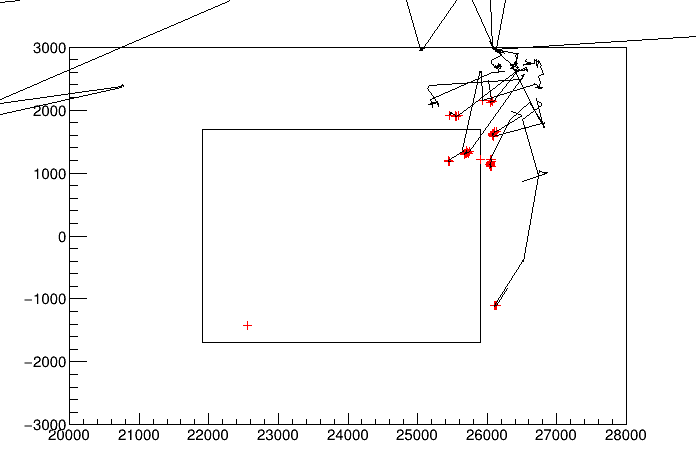

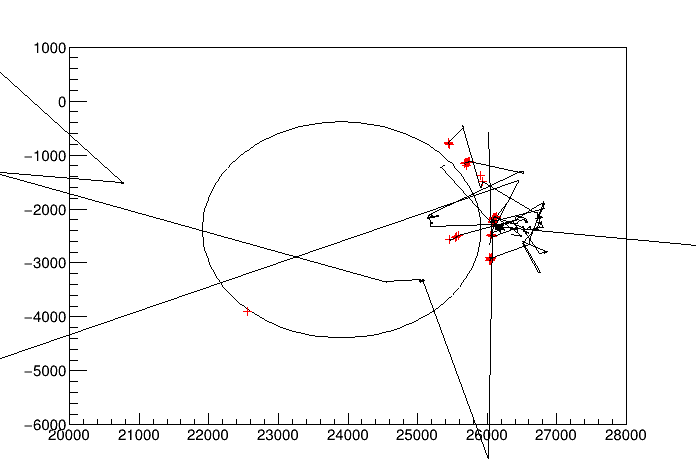

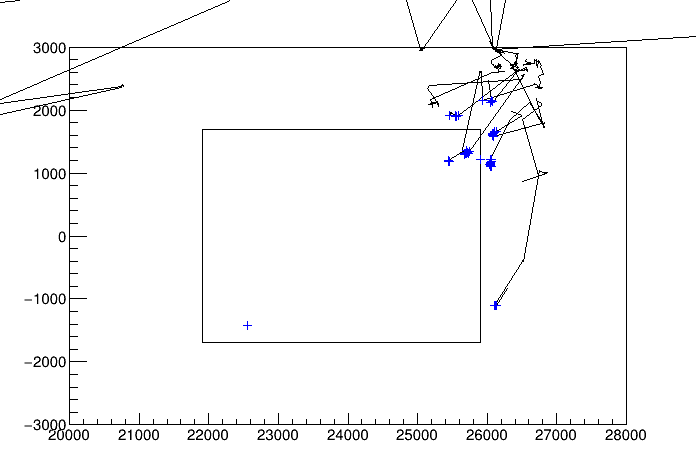

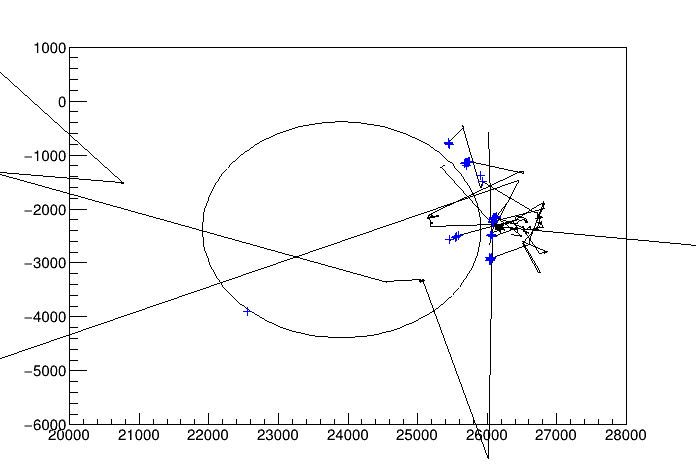

In [7]:
sp_id = 0
ev_id = 0
ev_seg = []
ev_mrk = []
tedep.GetEntry(sp_id)
ev_id = tedep.Event.Primaries.size()-1
frst_trk_id = tedep.Event.Primaries[ev_id].Particles.front().GetTrackId()
last_trk_id = tedep.Event.Primaries[ev_id].Particles.back().GetTrackId()
entry = 0
sy = ROOT.TEllipse(master[2],master[1],2000)
sx = ROOT.TBox(master[2]-2000,master[0]-1690,master[2]+2000,master[0]+1690)
sx.SetFillStyle(0)
cx = ROOT.TCanvas()
cy = ROOT.TCanvas()
cex = ROOT.TCanvas()
cey = ROOT.TCanvas()
cey.cd()
cey.DrawFrame(20000,-6000,28000,1000)
sy.Draw()
cex.cd()
cex.DrawFrame(20000,-3000,28000,3000)
sx.Draw()
cy.cd()
cy.DrawFrame(20000,-6000,28000,1000)
sy.Draw()
cx.cd()
cx.DrawFrame(20000,-3000,28000,3000)
sx.Draw()

while True:
    thits.GetEntry(entry)
    if thits.spl_id == sp_id and thits.evt_id == ev_id:
        for i in range(thits.hit_z.size()):
            mrk = ROOT.TMarker(thits.hit_z[i],thits.hit_y[i],2)
            mrk.SetMarkerColor(ROOT.kRed)
            ev_mrk.append(mrk)
            cy.cd()
            mrk.Draw()
            mrk = ROOT.TMarker(thits.hit_z[i],thits.hit_x[i],2)
            mrk.SetMarkerColor(ROOT.kRed)
            ev_mrk.append(mrk)
            cx.cd()
            mrk.Draw()
    entry += 1
    if entry >= thits.GetEntries():
        break
        
for trk in tedep.Event.Trajectories:
    # check if trk is of the event
    prm_trk = trk
    while True:
        if prm_trk.GetParentId() == -1:
            break
        else:
            prm_trk = tedep.Event.Trajectories[prm_trk.GetParentId()]
    if prm_trk.GetTrackId() >= frst_trk_id and prm_trk.GetTrackId() <= last_trk_id:
        # if it belong to the event, draw segments
        for idx in range(trk.Points.size()-1):
            seg = ROOT.TLine(trk.Points[idx].GetPosition().Z(), trk.Points[idx].GetPosition().Y(), trk.Points[idx+1].GetPosition().Z(), trk.Points[idx+1].GetPosition().Y())
            ev_seg.append(seg)
            cy.cd()
            seg.Draw()
            cey.cd()
            seg.Draw()
            seg = ROOT.TLine(trk.Points[idx].GetPosition().Z(), trk.Points[idx].GetPosition().X(), trk.Points[idx+1].GetPosition().Z(), trk.Points[idx+1].GetPosition().X())
            ev_seg.append(seg)
            cx.cd()
            seg.Draw()
            cex.cd()
            seg.Draw()
for vht in tedep.Event.SegmentDetectors:
    if vht.first in ["EMCalSci","DriftVolume"]:
        for ht in vht.second:
            prm_trk = tedep.Event.Trajectories[ht.GetPrimaryId()]
            while True:
                if prm_trk.GetParentId() == -1:
                    break
                else:
                    prm_trk = tedep.Event.Trajectories[prm_trk.GetParentId()]
            if prm_trk.GetTrackId() >= frst_trk_id and prm_trk.GetTrackId() <= last_trk_id:
                mrk = ROOT.TMarker(0.5*(ht.GetStart().Z() + ht.GetStop().Z()), 0.5*(ht.GetStart().Y() + ht.GetStop().Y()),2)
                mrk.SetMarkerColor(ROOT.kBlue)
                ev_mrk.append(mrk)
                cey.cd()
                mrk.Draw()
                mrk = ROOT.TMarker(0.5*(ht.GetStart().Z() + ht.GetStop().Z()), 0.5*(ht.GetStart().X() + ht.GetStop().X()),2)
                mrk.SetMarkerColor(ROOT.kBlue)
                ev_mrk.append(mrk)
                cex.cd()
                mrk.Draw()
            

cy.Draw()
cx.Draw()
cey.Draw()
cex.Draw()
            